In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

simrnstha_intel_image_classification_path = kagglehub.dataset_download('simrnstha/intel-image-classification')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/simrnstha/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/simrnstha/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/simrnstha/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/simrnstha/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/simrnstha/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/simrnstha/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/simrnstha/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/simrnstha/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/simrnstha/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/simrnstha/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggle/input/da

# Part II: Image Classification with CNN

- This notebook performs image classification using deep learning.
- It includes data analysis, preprocessing, CNN model building, training, evaluation, and comparison.
- CNN models from scratch and transfer learning models are implemented.


In [ ]:
# =========================
# 1. Import Libraries
# =========================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## 2. Dataset Description

- Define dataset paths for training and testing images.
- Define class names used for classification.
- Set batch size, validation split, image size, and number of classes.


In [ ]:
CLASS_NAMES = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

TRAIN_DIR = "/kaggle/input/datasets/simrnstha/intel-image-classification/seg_train/seg_train"
TEST_DIR = "/kaggle/input/datasets/simrnstha/intel-image-classification/seg_test/seg_test"

BATCH_SIZE = 32
SEED = 42
VALIDATION_SPLIT = 0.2
NUM_CLASSES = len(CLASS_NAMES)
IMAGE_SIZE = (150, 150)


## 3. Data Understanding and Class Distribution

- Count the number of images in each class.
- Check total training and testing images.
- Analyze whether the dataset is balanced or imbalanced.


In [ ]:
def count_images_per_class(directory):
    data = []

    for class_name in CLASS_NAMES:
        class_path = os.path.join(directory, class_name)
        count = len(os.listdir(class_path)) if os.path.exists(class_path) else 0

        data.append({
            "class_name": class_name,
            "count": count
        })

    return pd.DataFrame(data)


train_distribution = count_images_per_class(TRAIN_DIR)
test_distribution = count_images_per_class(TEST_DIR)

print("Training Set Distribution")
display(train_distribution)

print("Testing Set Distribution")
display(test_distribution)

print("Total training images:", train_distribution["count"].sum())
print("Total testing images:", test_distribution["count"].sum())


Training Set Distribution


,class_name,count
0,buildings,2191
1,forest,2271
2,glacier,2404
3,mountain,2512
4,sea,2274
5,street,2382


Testing Set Distribution


,class_name,count
0,buildings,437
1,forest,474
2,glacier,553
3,mountain,525
4,sea,510
5,street,501


Total training images: 14034
Total testing images: 3000


## 4. Data Visualization

- Plot class distribution using bar charts.
- Display sample images from each class.
- Understand visual differences between image categories.


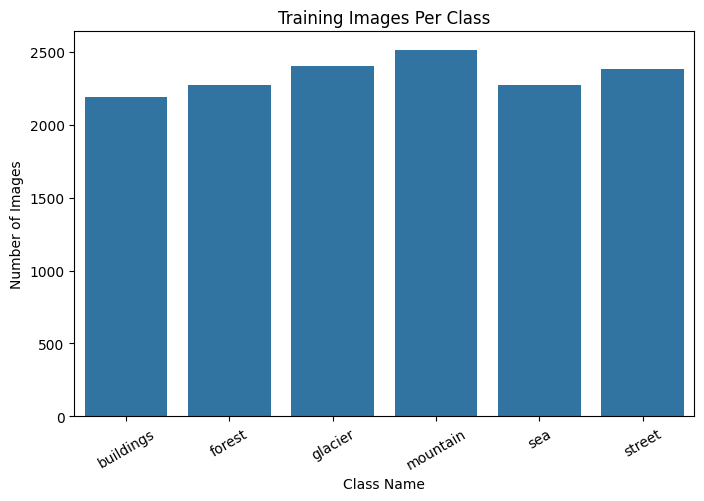

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=train_distribution, x="class_name", y="count")
plt.title("Training Images Per Class")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()


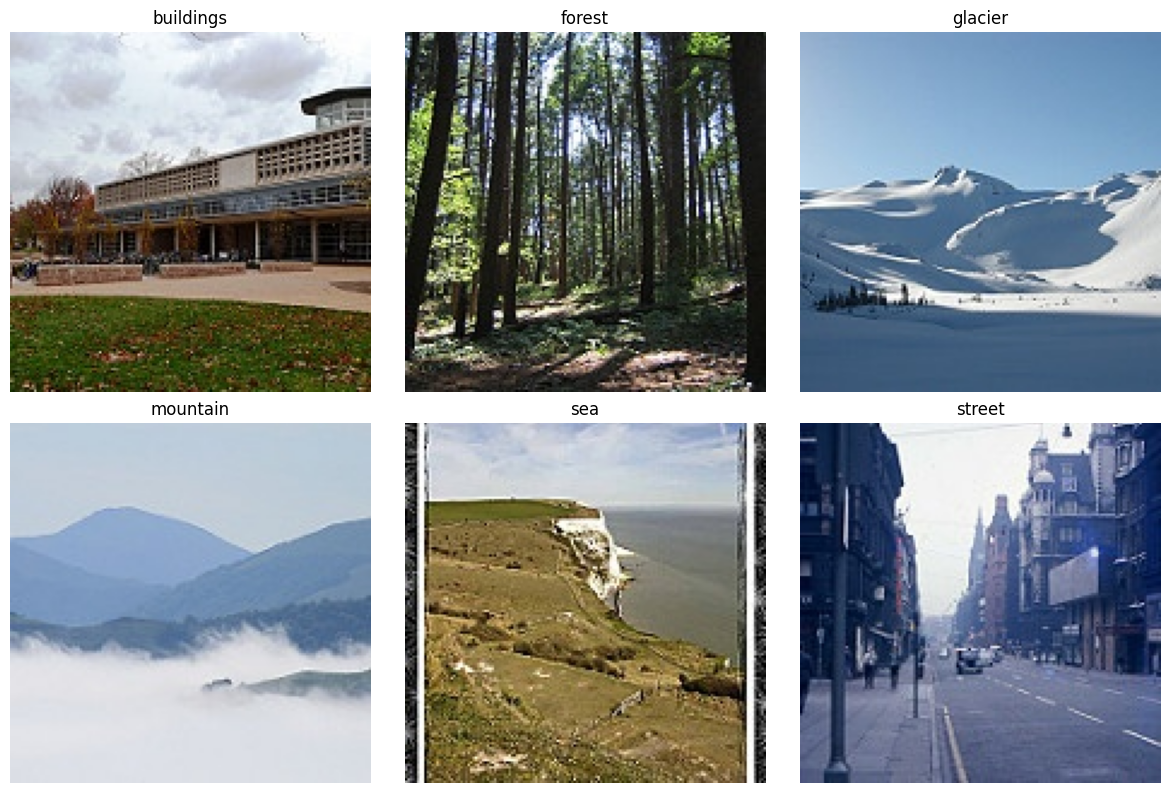

In [ ]:
def show_sample_images(directory):
    plt.figure(figsize=(12, 8))

    for i, class_name in enumerate(CLASS_NAMES):
        class_path = os.path.join(directory, class_name)
        image_name = os.listdir(class_path)[0]
        image_path = os.path.join(class_path, image_name)

        img = tf.keras.utils.load_img(image_path, target_size=IMAGE_SIZE)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_sample_images(TRAIN_DIR)


## 5. Data Preprocessing and Augmentation

- Resize all images to a fixed size.
- Normalize pixel values from 0-255 to 0-1.
- Apply augmentation only to training data.
- Create separate generators for training, validation, and testing.


In [ ]:
def create_generators(image_size=(150, 150), augment=True):
    if augment:
        train_datagen = ImageDataGenerator(
            rescale=1.0 / 255.0,
            validation_split=VALIDATION_SPLIT,
            rotation_range=20,
            width_shift_range=0.12,
            height_shift_range=0.12,
            zoom_range=0.15,
            shear_range=0.1,
            horizontal_flip=True,
            fill_mode="nearest"
        )
    else:
        train_datagen = ImageDataGenerator(
            rescale=1.0 / 255.0,
            validation_split=VALIDATION_SPLIT
        )

    val_datagen = ImageDataGenerator(
        rescale=1.0 / 255.0,
        validation_split=VALIDATION_SPLIT
    )

    test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=image_size,
        batch_size=BATCH_SIZE,
        classes=CLASS_NAMES,
        class_mode="categorical",
        subset="training",
        shuffle=True,
        seed=SEED
    )

    val_gen = val_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=image_size,
        batch_size=BATCH_SIZE,
        classes=CLASS_NAMES,
        class_mode="categorical",
        subset="validation",
        shuffle=False,
        seed=SEED
    )

    test_gen = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=image_size,
        batch_size=BATCH_SIZE,
        classes=CLASS_NAMES,
        class_mode="categorical",
        shuffle=False
    )

    return train_gen, val_gen, test_gen


train_gen, val_gen, test_gen = create_generators(image_size=IMAGE_SIZE, augment=True)


Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


## 6. Visualizing Augmented Images

- Display augmented versions of a sample training image.
- Check rotation, shifting, zooming, shearing, and flipping.
- Verify that augmentation is working correctly.


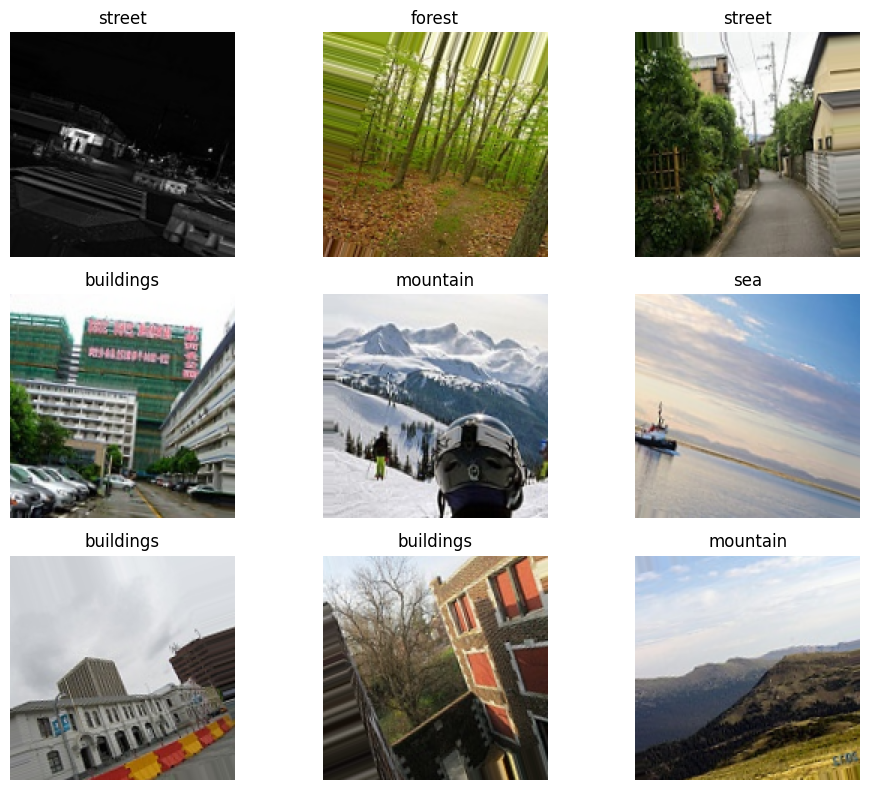

In [ ]:
def show_augmented_images(generator, num_images=9):
    images, labels = next(generator)

    plt.figure(figsize=(10, 8))

    for i in range(num_images):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        class_index = np.argmax(labels[i])
        plt.title(CLASS_NAMES[class_index])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_augmented_images(train_gen)


## 7. Baseline CNN Model

- Build a CNN model from scratch.
- Use three convolutional layers.
- Add max pooling after each convolutional layer.
- Add three fully connected dense layers.
- Add softmax output layer for multi-class classification.


In [ ]:
def build_baseline_cnn(input_shape=(150, 150, 3), num_classes=6):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),

        layers.Dense(num_classes, activation="softmax")
    ])

    return model


baseline_model = build_baseline_cnn(
    input_shape=(150, 150, 3),
    num_classes=NUM_CLASSES
)


I0000 00:00:1778744117.104453      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778744117.110506      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 8. Baseline Model Summary

- Print the baseline model architecture.
- Check output shape of each layer.
- Check total trainable parameters.
- Understand baseline model complexity.


In [ ]:
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,751,878 (41.02 MB)

 Trainable params: 10,751,878 (41.02 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Training the Baseline CNN Model

- Compile the baseline model using Adam optimizer.
- Use categorical cross-entropy loss.
- Train the model for a suitable number of epochs.
- Record total training time.


In [ ]:
def make_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=7,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-6
        )
    ]


In [ ]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

baseline_history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=make_callbacks()
)

baseline_training_time = time.time() - start_time

print(f"Baseline training time: {baseline_training_time:.2f} seconds")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1778744121.369692     269 service.cc:152] XLA service 0x7dc46000ed30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778744121.369730     269 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778744121.369734     269 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778744121.903900     269 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-14 07:35:23.949742: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 07:35:24.098720: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/351 ━━━━━━━━━━━━━━━━━━━━ 41:30 7s/step - accuracy: 0.1250 - loss: 1.7944

I0000 00:00:1778744126.331081     269 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


256/351 ━━━━━━━━━━━━━━━━━━━━ 30s 320ms/step - accuracy: 0.4145 - loss: 1.4320

2026-05-14 07:36:49.640794: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 07:36:49.789321: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


351/351 ━━━━━━━━━━━━━━━━━━━━ 135s 364ms/step - accuracy: 0.4454 - loss: 1.3597 - val_accuracy: 0.6576 - val_loss: 0.9002 - learning_rate: 0.0010
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 90s 257ms/step - accuracy: 0.6519 - loss: 0.9171 - val_accuracy: 0.6787 - val_loss: 0.8576 - learning_rate: 0.0010
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 87s 247ms/step - accuracy: 0.7159 - loss: 0.7587 - val_accuracy: 0.7885 - val_loss: 0.5795 - learning_rate: 0.0010
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 77s 218ms/step - accuracy: 0.7508 - loss: 0.6822 - val_accuracy: 0.7407 - val_loss: 0.6998 - learning_rate: 0.0010
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 239ms/step - accuracy: 0.7758 - loss: 0.6191 - val_accuracy: 0.8174 - val_loss: 0.5236 - learning_rate: 0.0010
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 209ms/step - accuracy: 0.7925 - loss: 0.5648 - val_accuracy: 0.8331 - val_loss: 0.4821 - learning_rate: 0.0010
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 76s 216ms/step - accuracy: 0.8058 - loss

## 10. Baseline Training Curves

- Plot training and validation loss.
- Plot training and validation accuracy.
- Check learning behavior.
- Identify possible overfitting or underfitting.


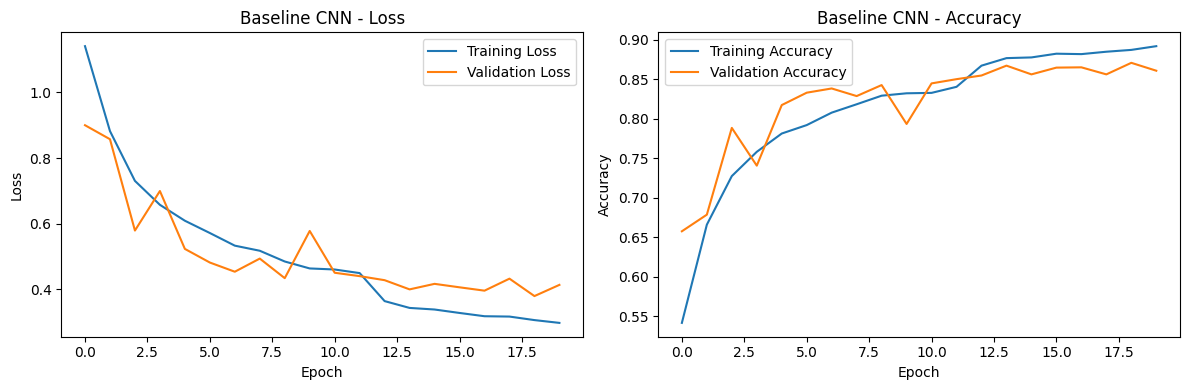

In [ ]:
def plot_training_curves(history, title):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history_df["loss"], label="Training Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_df["accuracy"], label="Training Accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_training_curves(baseline_history, "Baseline CNN")


## 11. Baseline Model Evaluation

- Evaluate the baseline model on the test dataset.
- Calculate accuracy, precision, recall, and F1-score.
- Display classification report.
- Plot confusion matrix.


94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 197ms/step

Baseline CNN Evaluation
Accuracy: 0.8643333333333333
Weighted Precision: 0.8638281394299505
Weighted Recall: 0.8643333333333333
Weighted F1 Score: 0.8636800999238166

Classification Report:
              precision    recall  f1-score   support

   buildings       0.83      0.87      0.85       437
      forest       0.96      0.98      0.97       474
     glacier       0.83      0.80      0.82       553
    mountain       0.84      0.77      0.80       525
         sea       0.86      0.88      0.87       510
      street       0.87      0.90      0.88       501

    accuracy                           0.86      3000
   macro avg       0.86      0.87      0.87      3000
weighted avg       0.86      0.86      0.86      3000



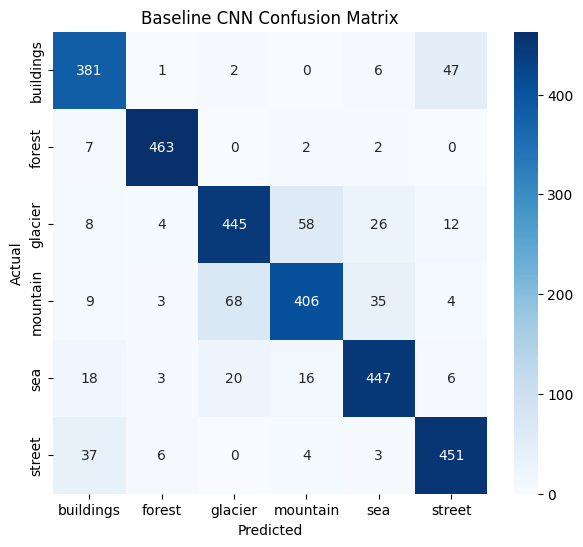

In [ ]:
def evaluate_model(model, generator, model_name):
    generator.reset()

    predictions = model.predict(generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes

    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n{model_name} Evaluation")
    print("Accuracy:", accuracy)
    print("Weighted Precision:", precision)
    print("Weighted Recall:", recall)
    print("Weighted F1 Score:", f1)

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(model_name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }


baseline_metrics = evaluate_model(baseline_model, test_gen, "Baseline CNN")
baseline_metrics["training_time"] = baseline_training_time


## 12. Baseline Sample Predictions

- Select sample test images.
- Predict their classes using the baseline model.
- Compare predicted labels with actual labels.
- Visualize correct and incorrect predictions.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step


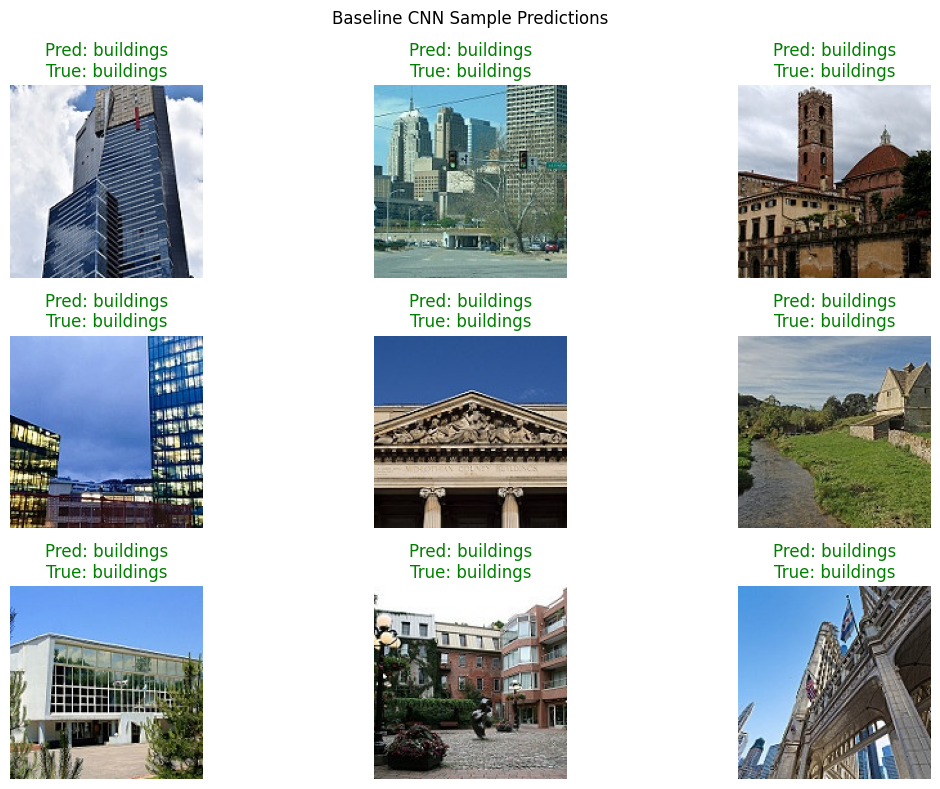

In [ ]:
def plot_sample_predictions(model, generator, title):
    generator.reset()
    images, labels = next(generator)

    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(labels, axis=1)

    plt.figure(figsize=(12, 8))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])

        pred_label = CLASS_NAMES[predicted_classes[i]]
        true_label = CLASS_NAMES[true_classes[i]]
        color = "green" if pred_label == true_label else "red"

        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_sample_predictions(baseline_model, test_gen, "Baseline CNN Sample Predictions")


## 13. Deeper CNN Model with Regularization

- Build a deeper CNN model from scratch.
- Use at least double the convolutional layers compared to the baseline.
- Add Batch Normalization for stable training.
- Add Dropout to reduce overfitting.
- Use softmax output layer for classification.


In [ ]:
def build_deeper_cnn(
    input_shape=(150, 150, 3),
    num_classes=6,
    use_batch_norm=True,
    use_dropout=True
):
    inputs = layers.Input(shape=input_shape)
    x = inputs

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
        if use_batch_norm:
            x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)

        x = layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
        if use_batch_norm:
            x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)

        x = layers.MaxPooling2D((2, 2))(x)

        if use_dropout:
            x = layers.Dropout(0.15)(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    if use_dropout:
        x = layers.Dropout(0.25)(x)

    x = layers.Dense(128, activation="relu")(x)
    if use_dropout:
        x = layers.Dropout(0.20)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model


deeper_model = build_deeper_cnn(
    input_shape=(150, 150, 3),
    num_classes=NUM_CLASSES
)


## 14. Deeper Model Summary

- Print the deeper CNN architecture.
- Compare number of layers with baseline model.
- Check number of trainable parameters.
- Analyze how the deeper model differs from baseline.


In [ ]:
deeper_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 37, 37, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 355,046 (1.35 MB)

 Trainable params: 354,150 (1.35 MB)

 Non-trainable params: 896 (3.50 KB)

## 15. Training the Deeper CNN Model

- Compile the deeper model using Adam optimizer.
- Train for more epochs than the baseline if needed.
- Use fresh callbacks for this model.
- Record total training time.


In [ ]:
deeper_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

deeper_history = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=make_callbacks()
)

deeper_training_time = time.time() - start_time

print(f"Deeper CNN training time: {deeper_training_time:.2f} seconds")


Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 115s 300ms/step - accuracy: 0.8207 - loss: 0.4945 - val_accuracy: 0.7097 - val_loss: 1.1215 - learning_rate: 5.0000e-04
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 76s 216ms/step - accuracy: 0.8301 - loss: 0.4717 - val_accuracy: 0.8203 - val_loss: 0.4992 - learning_rate: 5.0000e-04
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 239ms/step - accuracy: 0.8363 - loss: 0.4542 - val_accuracy: 0.6612 - val_loss: 0.9820 - learning_rate: 5.0000e-04
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 226ms/step - accuracy: 0.8381 - loss: 0.4471 - val_accuracy: 0.7914 - val_loss: 0.6245 - learning_rate: 5.0000e-04
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 211ms/step - accuracy: 0.8417 - loss: 0.4381 - val_accuracy: 0.7867 - val_loss: 0.6123 - learning_rate: 5.0000e-04
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 243ms/step - accuracy: 0.8633 - loss: 0.3845 - val_accuracy: 0.7956 - val_loss: 0.6205 - learning_rate: 1.5000e-04
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 93s 2

## 16. Deeper Model Training Curves

- Plot training and validation loss for the deeper model.
- Plot training and validation accuracy.
- Compare learning behavior with baseline.
- Check whether the model is overfitting or underfitting.


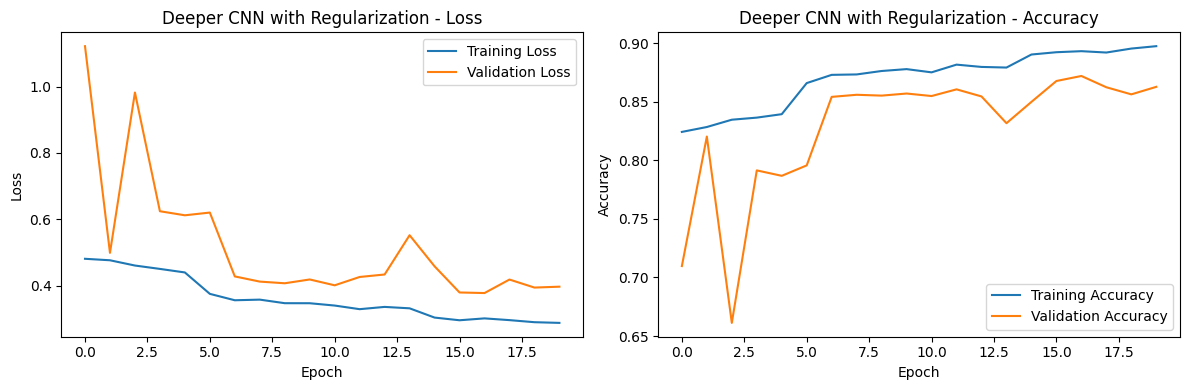

In [ ]:
plot_training_curves(deeper_history, "Deeper CNN with Regularization")


## 17. Deeper Model Evaluation

- Evaluate the deeper model on the same test dataset.
- Use the same metrics as the baseline model.
- Calculate accuracy, precision, recall, and F1-score.
- Plot confusion matrix and classification report.


94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 181ms/step

Deeper CNN Evaluation
Accuracy: 0.8616666666666667
Weighted Precision: 0.8624510561902536
Weighted Recall: 0.8616666666666667
Weighted F1 Score: 0.8613064933452578

Classification Report:
              precision    recall  f1-score   support

   buildings       0.83      0.83      0.83       437
      forest       0.94      0.97      0.96       474
     glacier       0.79      0.87      0.83       553
    mountain       0.85      0.77      0.81       525
         sea       0.88      0.87      0.87       510
      street       0.89      0.87      0.88       501

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



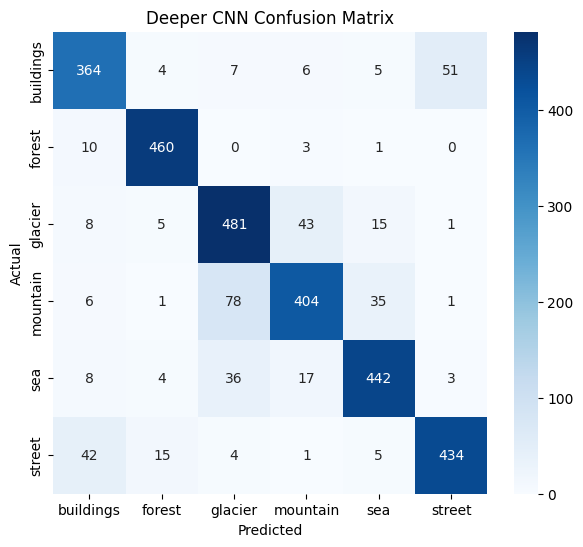

In [ ]:
deeper_metrics = evaluate_model(deeper_model, test_gen, "Deeper CNN")
deeper_metrics["training_time"] = deeper_training_time


## 18. Baseline vs Deeper CNN Comparison

- Compare baseline and deeper model accuracy.
- Compare precision, recall, and F1-score.
- Compare training time.
- Discuss whether adding more layers improved performance.


In [ ]:
part_a_results = pd.DataFrame([
    baseline_metrics,
    deeper_metrics
])

display(part_a_results)


,model,accuracy,precision,recall,f1_score,training_time
0,Baseline CNN,0.864333,0.863828,0.864333,0.863680,1570.174872
1,Deeper CNN,0.861667,0.862451,0.861667,0.861306,1696.452988


## 19. Optimizer Analysis: Adam vs SGD

- Train the deeper CNN model using Adam optimizer.
- Train another deeper CNN model using SGD optimizer.
- Compare convergence speed.
- Compare final accuracy and validation loss.


Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 113s 301ms/step - accuracy: 0.4485 - loss: 1.3033 - val_accuracy: 0.4857 - val_loss: 1.4707 - learning_rate: 0.0100
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 78s 221ms/step - accuracy: 0.6322 - loss: 0.9296 - val_accuracy: 0.6830 - val_loss: 0.8088 - learning_rate: 0.0100
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 76s 215ms/step - accuracy: 0.6965 - loss: 0.8031 - val_accuracy: 0.7004 - val_loss: 0.7730 - learning_rate: 0.0100
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 209ms/step - accuracy: 0.7370 - loss: 0.7219 - val_accuracy: 0.4897 - val_loss: 1.8976 - learning_rate: 0.0100
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 212ms/step - accuracy: 0.7431 - loss: 0.6994 - val_accuracy: 0.7471 - val_loss: 0.6423 - learning_rate: 0.0100
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 230ms/step - accuracy: 0.7594 - loss: 0.6408 - val_accuracy: 0.7507 - val_loss: 0.6970 - learning_rate: 0.0100
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 79s 224ms/step - accuracy: 0.

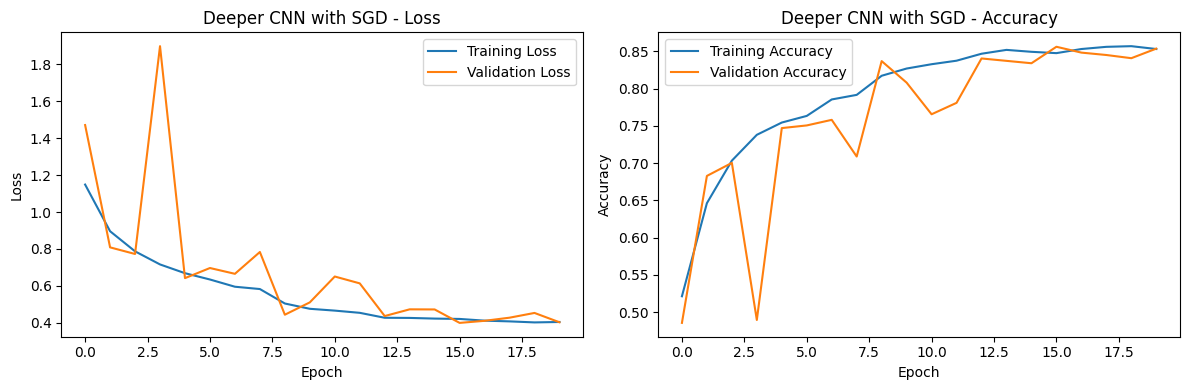

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step

Deeper CNN SGD Evaluation
Accuracy: 0.849
Weighted Precision: 0.8490862746653202
Weighted Recall: 0.849
Weighted F1 Score: 0.848358815380811

Classification Report:
              precision    recall  f1-score   support

   buildings       0.83      0.84      0.84       437
      forest       0.90      0.99      0.94       474
     glacier       0.80      0.83      0.81       553
    mountain       0.81      0.80      0.81       525
         sea       0.88      0.85      0.86       510
      street       0.88      0.81      0.84       501

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



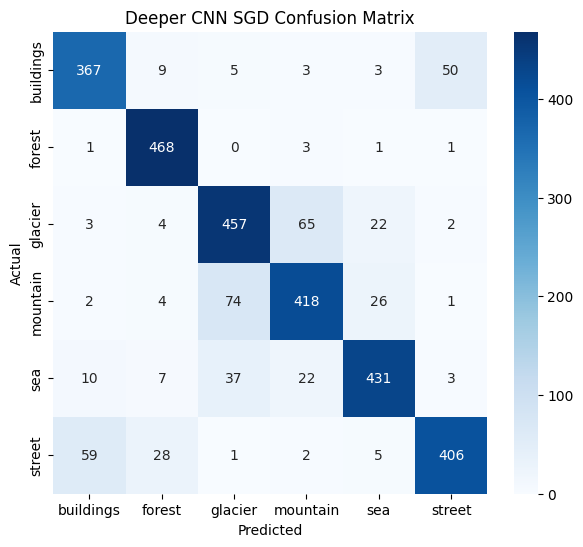

In [ ]:
sgd_model = build_deeper_cnn(
    input_shape=(150, 150, 3),
    num_classes=NUM_CLASSES
)

sgd_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

sgd_history = sgd_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=make_callbacks()
)

sgd_training_time = time.time() - start_time

print(f"Deeper CNN SGD training time: {sgd_training_time:.2f} seconds")

plot_training_curves(sgd_history, "Deeper CNN with SGD")

sgd_metrics = evaluate_model(sgd_model, test_gen, "Deeper CNN SGD")
sgd_metrics["training_time"] = sgd_training_time


## 20. Ablation Study

- Remove one component from the deeper model.
- In this experiment, Dropout is removed.
- Train and evaluate the modified model.
- Compare the result with the original deeper model.


Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 215ms/step - accuracy: 0.5520 - loss: 1.1057 - val_accuracy: 0.3902 - val_loss: 1.8229 - learning_rate: 5.0000e-04
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 211ms/step - accuracy: 0.7246 - loss: 0.7382 - val_accuracy: 0.5913 - val_loss: 1.3999 - learning_rate: 5.0000e-04
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 235ms/step - accuracy: 0.7520 - loss: 0.6615 - val_accuracy: 0.7397 - val_loss: 0.6838 - learning_rate: 5.0000e-04
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 208ms/step - accuracy: 0.7874 - loss: 0.5859 - val_accuracy: 0.5713 - val_loss: 1.2232 - learning_rate: 5.0000e-04
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 207ms/step - accuracy: 0.7953 - loss: 0.5498 - val_accuracy: 0.7743 - val_loss: 0.6286 - learning_rate: 5.0000e-04
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 211ms/step - accuracy: 0.8052 - loss: 0.5164 - val_accuracy: 0.6922 - val_loss: 0.8065 - learning_rate: 5.0000e-04
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 72s 20

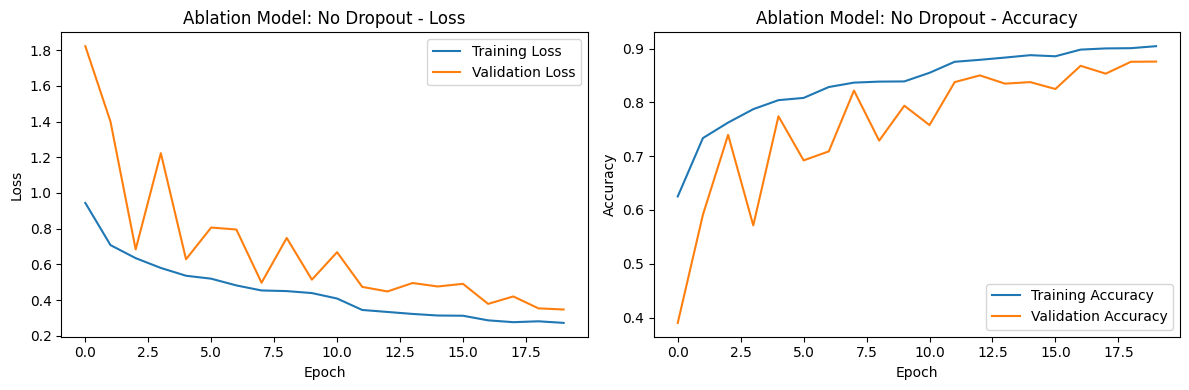

94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step

Ablation Model: No Dropout Evaluation
Accuracy: 0.8683333333333333
Weighted Precision: 0.8702562905680298
Weighted Recall: 0.8683333333333333
Weighted F1 Score: 0.868327581382456

Classification Report:
              precision    recall  f1-score   support

   buildings       0.79      0.90      0.84       437
      forest       0.97      0.98      0.97       474
     glacier       0.84      0.81      0.82       553
    mountain       0.82      0.82      0.82       525
         sea       0.90      0.90      0.90       510
      street       0.91      0.82      0.86       501

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



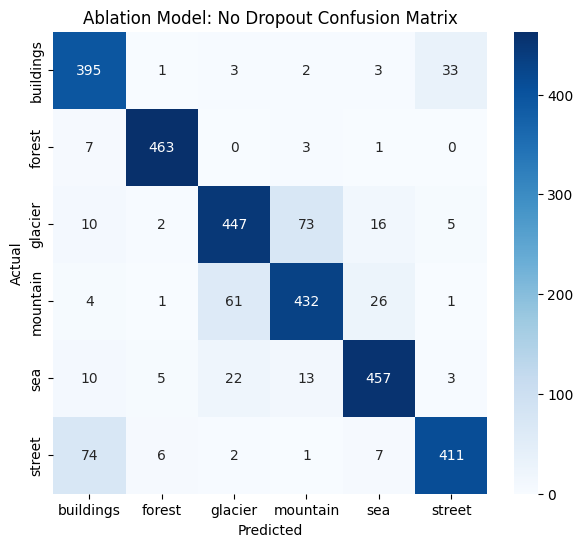

In [ ]:
ablation_model = build_deeper_cnn(
    input_shape=(150, 150, 3),
    num_classes=NUM_CLASSES,
    use_batch_norm=True,
    use_dropout=False
)

ablation_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

ablation_history = ablation_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=make_callbacks()
)

ablation_training_time = time.time() - start_time

print(f"Ablation model training time: {ablation_training_time:.2f} seconds")

plot_training_curves(ablation_history, "Ablation Model: No Dropout")

ablation_metrics = evaluate_model(ablation_model, test_gen, "Ablation Model: No Dropout")
ablation_metrics["training_time"] = ablation_training_time


## 21. Challenges and Observations

- Identify whether models show overfitting or underfitting.
- Discuss unstable validation loss if observed.
- Mention training time and computational cost.
- Mention whether GPU or TPU acceleration was used.


In [ ]:
scratch_results = pd.DataFrame([
    baseline_metrics,
    deeper_metrics,
    sgd_metrics,
    ablation_metrics
])

display(scratch_results)


,model,accuracy,precision,recall,f1_score,training_time
0,Baseline CNN,0.864333,0.863828,0.864333,0.863680,1570.174872
1,Deeper CNN,0.861667,0.862451,0.861667,0.861306,1696.452988
2,Deeper CNN SGD,0.849000,0.849086,0.849000,0.848359,1596.686389
3,Ablation Model: No Dropout,0.868333,0.870256,0.868333,0.868328,1537.531405


## 22. Transfer Learning with Pre-Trained Model

- Load MobileNetV2 with ImageNet weights.
- Remove the original classification layer.
- Add new classification layers for the selected dataset.
- Use transfer learning to improve performance.


In [ ]:
def create_transfer_generators(image_size=(224, 224)):
    preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        validation_split=VALIDATION_SPLIT,
        rotation_range=20,
        width_shift_range=0.12,
        height_shift_range=0.12,
        zoom_range=0.15,
        shear_range=0.1,
        horizontal_flip=True,
        fill_mode="nearest"
    )

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        validation_split=VALIDATION_SPLIT
    )

    test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    transfer_train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=image_size,
        batch_size=BATCH_SIZE,
        classes=CLASS_NAMES,
        class_mode="categorical",
        subset="training",
        shuffle=True,
        seed=SEED
    )

    transfer_val_gen = val_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=image_size,
        batch_size=BATCH_SIZE,
        classes=CLASS_NAMES,
        class_mode="categorical",
        subset="validation",
        shuffle=False,
        seed=SEED
    )

    transfer_test_gen = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=image_size,
        batch_size=BATCH_SIZE,
        classes=CLASS_NAMES,
        class_mode="categorical",
        shuffle=False
    )

    return transfer_train_gen, transfer_val_gen, transfer_test_gen


transfer_train_gen, transfer_val_gen, transfer_test_gen = create_transfer_generators()


Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

transfer_model = models.Model(inputs, outputs)

transfer_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 23. Feature Extraction

- Freeze the convolutional base of MobileNetV2.
- Train only the newly added classification layers.
- Use the pre-trained model as a feature extractor.
- Evaluate how useful ImageNet features are for this dataset.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


2026-05-14 10:07:14.576212: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 10:07:14.714041: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


147/351 ━━━━━━━━━━━━━━━━━━━━ 1:17 379ms/step - accuracy: 0.7032 - loss: 0.7785

2026-05-14 10:08:21.686976: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 10:08:21.824277: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.7744 - loss: 0.5958

2026-05-14 10:10:03.157609: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 10:10:03.313178: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 10:10:03.450488: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


351/351 ━━━━━━━━━━━━━━━━━━━━ 185s 481ms/step - accuracy: 0.7746 - loss: 0.5954 - val_accuracy: 0.8916 - val_loss: 0.2964 - learning_rate: 0.0010
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 144s 410ms/step - accuracy: 0.8834 - loss: 0.3199 - val_accuracy: 0.9055 - val_loss: 0.2663 - learning_rate: 0.0010
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 138s 392ms/step - accuracy: 0.8851 - loss: 0.3121 - val_accuracy: 0.9051 - val_loss: 0.2647 - learning_rate: 0.0010
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 134s 380ms/step - accuracy: 0.8921 - loss: 0.2915 - val_accuracy: 0.8976 - val_loss: 0.2861 - learning_rate: 0.0010
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 127s 362ms/step - accuracy: 0.8879 - loss: 0.2916 - val_accuracy: 0.9087 - val_loss: 0.2602 - learning_rate: 0.0010
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 128s 363ms/step - accuracy: 0.9010 - loss: 0.2682 - val_accuracy: 0.9108 - val_loss: 0.2550 - learning_rate: 0.0010
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 129s 367ms/step - accuracy: 0.9040 

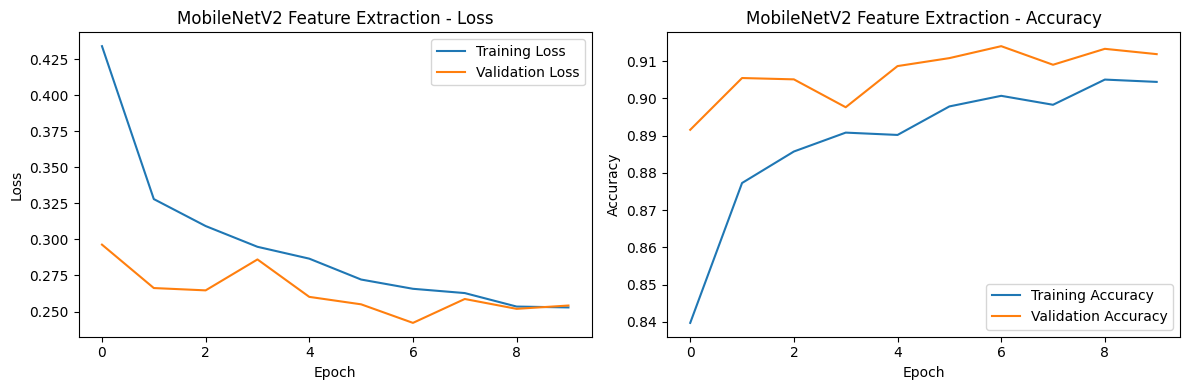

93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step

2026-05-14 10:30:29.592334: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 10:30:29.749145: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 10:30:29.886893: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 238ms/step

MobileNetV2 Feature Extraction Evaluation
Accuracy: 0.915
Weighted Precision: 0.9145521664993178
Weighted Recall: 0.915
Weighted F1 Score: 0.9144888004080141

Classification Report:
              precision    recall  f1-score   support

   buildings       0.92      0.93      0.92       437
      forest       0.98      0.99      0.99       474
     glacier       0.85      0.86      0.85       553
    mountain       0.88      0.82      0.85       525
         sea       0.93      0.98      0.96       510
      street       0.93      0.93      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.91      0.92      0.91      3000



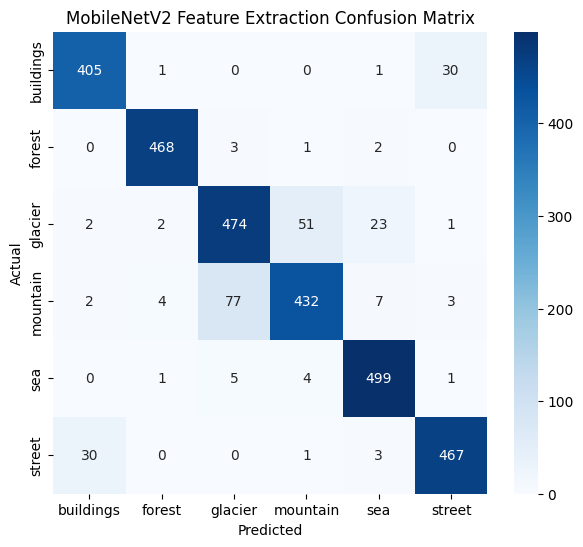

In [ ]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

feature_history = transfer_model.fit(
    transfer_train_gen,
    validation_data=transfer_val_gen,
    epochs=10,
    callbacks=make_callbacks()
)

feature_training_time = time.time() - start_time

print(f"Feature extraction training time: {feature_training_time:.2f} seconds")

plot_training_curves(feature_history, "MobileNetV2 Feature Extraction")

feature_metrics = evaluate_model(
    transfer_model,
    transfer_test_gen,
    "MobileNetV2 Feature Extraction"
)

feature_metrics["training_time"] = feature_training_time


## 24. Fine-Tuning the Pre-Trained Model

- Unfreeze some final layers of MobileNetV2.
- Keep earlier layers frozen.
- Train using a very low learning rate.
- Adapt pre-trained features to the selected dataset.


Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 162s 418ms/step - accuracy: 0.7907 - loss: 0.5748 - val_accuracy: 0.9073 - val_loss: 0.2530 - learning_rate: 1.0000e-05
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 131s 372ms/step - accuracy: 0.8745 - loss: 0.3341 - val_accuracy: 0.9069 - val_loss: 0.2493 - learning_rate: 1.0000e-05
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 137s 391ms/step - accuracy: 0.8933 - loss: 0.2918 - val_accuracy: 0.9123 - val_loss: 0.2447 - learning_rate: 1.0000e-05
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 164s 467ms/step - accuracy: 0.8987 - loss: 0.2780 - val_accuracy: 0.9094 - val_loss: 0.2427 - learning_rate: 1.0000e-05
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 149s 423ms/step - accuracy: 0.9067 - loss: 0.2488 - val_accuracy: 0.9162 - val_loss: 0.2316 - learning_rate: 1.0000e-05
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 141s 400ms/step - accuracy: 0.9084 - loss: 0.2474 - val_accuracy: 0.9119 - val_loss: 0.2349 - learning_rate: 1.0000e-05
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 

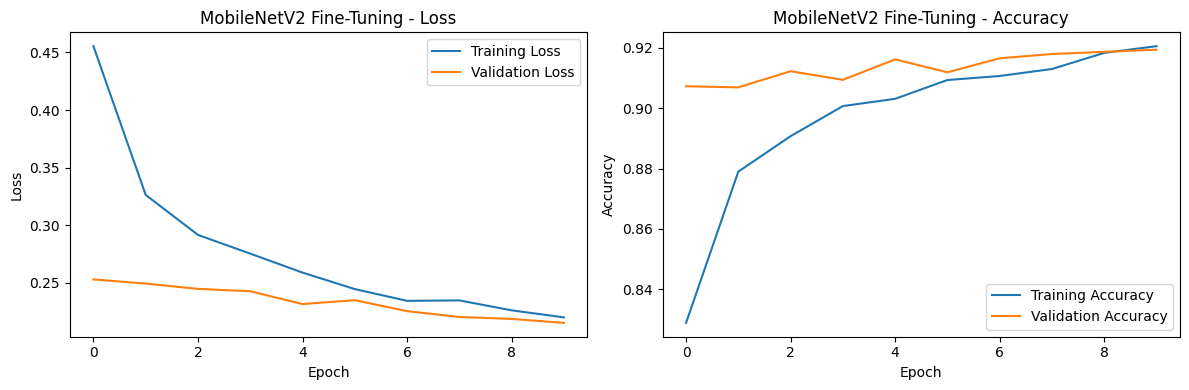

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

finetune_history = transfer_model.fit(
    transfer_train_gen,
    validation_data=transfer_val_gen,
    epochs=10,
    callbacks=make_callbacks()
)

finetune_training_time = time.time() - start_time

print(f"Fine-tuning training time: {finetune_training_time:.2f} seconds")

plot_training_curves(finetune_history, "MobileNetV2 Fine-Tuning")


## 25. Transfer Learning Evaluation

- Evaluate the fine-tuned model on the test dataset.
- Calculate accuracy, precision, recall, and F1-score.
- Plot confusion matrix.
- Compare transfer learning with CNN models trained from scratch.


94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 143ms/step

MobileNetV2 Fine-Tuned Evaluation
Accuracy: 0.9236666666666666
Weighted Precision: 0.9231256729739925
Weighted Recall: 0.9236666666666666
Weighted F1 Score: 0.9231439059054954

Classification Report:
              precision    recall  f1-score   support

   buildings       0.94      0.92      0.93       437
      forest       0.98      0.99      0.99       474
     glacier       0.89      0.85      0.87       553
    mountain       0.87      0.86      0.87       525
         sea       0.93      0.98      0.96       510
      street       0.94      0.95      0.94       501

    accuracy                           0.92      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.92      0.92      0.92      3000



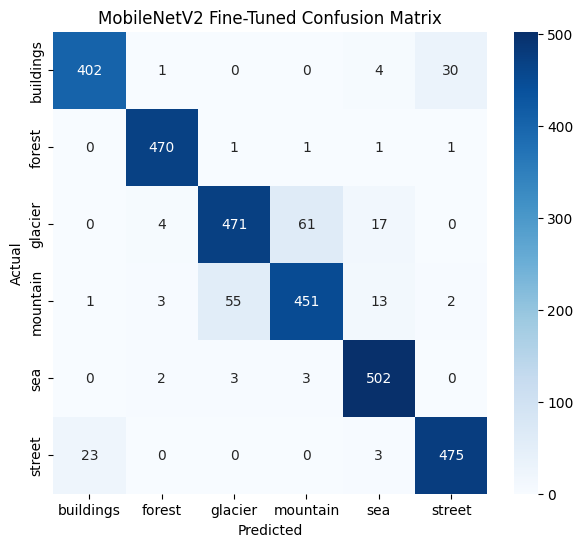

In [ ]:
finetune_metrics = evaluate_model(
    transfer_model,
    transfer_test_gen,
    "MobileNetV2 Fine-Tuned"
)

finetune_metrics["training_time"] = finetune_training_time


## 26. Final Model Comparison

- Create a final table of all trained models.
- Compare baseline CNN, deeper CNN, optimizer model, ablation model, and transfer learning model.
- Include accuracy, precision, recall, F1-score, and training time.
- Identify the best-performing model.


In [ ]:
all_results = pd.DataFrame([
    baseline_metrics,
    deeper_metrics,
    sgd_metrics,
    ablation_metrics,
    feature_metrics,
    finetune_metrics
])

display(all_results)


,model,accuracy,precision,recall,f1_score,training_time
0,Baseline CNN,0.864333,0.863828,0.864333,0.863680,1570.174872
1,Deeper CNN,0.861667,0.862451,0.861667,0.861306,1696.452988
2,Deeper CNN SGD,0.849000,0.849086,0.849000,0.848359,1596.686389
3,Ablation Model: No Dropout,0.868333,0.870256,0.868333,0.868328,1537.531405
4,MobileNetV2 Feature Extraction,0.915000,0.914552,0.915000,0.914489,1385.415262
5,MobileNetV2 Fine-Tuned,0.923667,0.923126,0.923667,0.923144,1414.954779


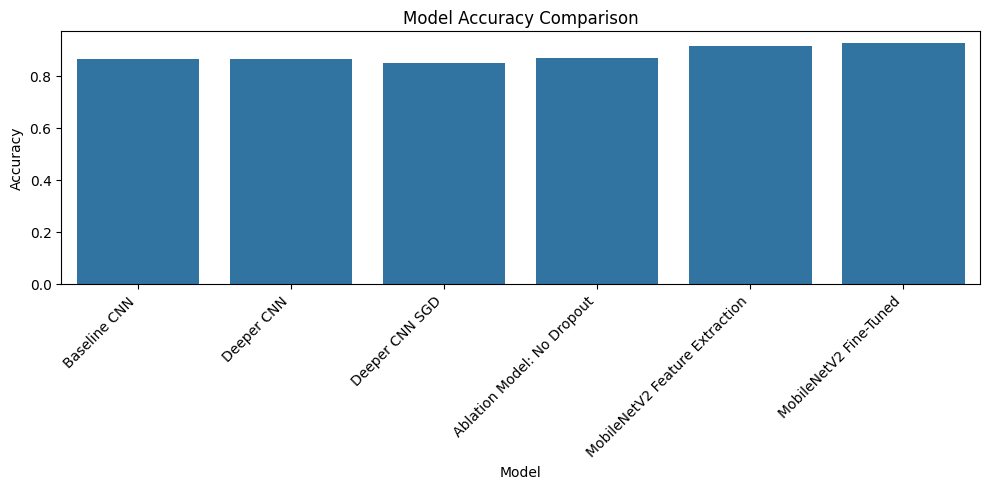

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=all_results, x="model", y="accuracy")
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
